---   
 <img align="left" width="75" height="75"  src="https://upload.wikimedia.org/wikipedia/en/c/c8/University_of_the_Punjab_logo.png"> 

<h1 align="center">Department of Data Science</h1>
<h1 align="center">Course: Tools and Techniques for Data Science</h1>

---
<h3><div align="right">Instructor: Muhammad Arif Butt, Ph.D.</div></h3>    

<h1 align="center">Lecture 6.7 (Preprocessing/Feature Engineering - Handling Outliers)</h1>

<a href="https://colab.research.google.com/github/arifpucit/data-science/blob/master/Section-4-Mathematics-for-Data-Science/Lec-4.1(Descriptive-Statistics).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# <img align="center" width="900" src="images/ml-topimg1.png"  >

# Learning agenda of this notebook

1. Overview of Data Pre-Processing and Feature Engineering
2. Detecting and Handling Outliers
    - Univariate Analysis
        - Z-Score Method
        - IQR Method
        - Percentile Method
    - Multivariate Analysis

# Overview of  Data Pre-Processing and Feature Engineering
- `Data Preprocessing` involves actions that we need to perform on the dataset in order to make it ready to be fed to the machine learning model.
- `Feature Engineering` is the process of using domain knowledge to extract features from raw data via data mining techniques.<br><br>

<img align="center" width="800" src="images/housing-dataset3.png"  >
<br><br>

- Pre-processing package of sklearn provides a bundle of utility functions and transformer classes for data preprocessing (will cover later).
    - **Detecting and handling outliers** 
        - Univariate (Z-Score, IQR, Percentiles)
        - Multivariate Analysis (Depth-based, Distance-based, Density-based methods)
        - Trimming, Capping/Winsorization, Discritization
    - **Missing values Imputation** 
        - Univariate Imputation (Panda's `fillna()` method, Sklearn's `SimpleImputer()` transformer)
        - Multivariate Imputation (Sklearn's `IterativeImputer()` and  `KNNImputer()` transformers)
    - **Encoding Categorical Features**
        - Encode Nominal i/p features using Pandas `get_dummies()` and Scikit-Learn's `OneHotEncoder()`  
        - Encode Ordinal i/p features using Scikit-Learn's `OrdinalEncoder()`
        - Encode categorical o/p label using Scikit-Learn's `LabelEncoder()`
    - **Feature Scaling**
        - Use numPy to perform maxabs, minmax, standard and robust scaling
        - Use Sklearn's `MaxAbsScalar` , `MinMaxScalar`, `StandardScalar`, `RobustScalar` transformers
    - **Extracting Information** 
        - Use Sklearn's `CountVectorizer`, `DictVectorizer` , `TfidfVectorizer`, and `TfidfTransformer`
    - **Combining Information**
        - Use `FeatureUnion`, `Pipeline`, `PCA`

# What are Outliers and How to Deal with them?
<center><h3 align="center"><div class="alert alert-success" style="margin: 20px">An outlier is a data point that differs significantly from other observations</h3></center>

- Every data science project starts with collection of data and that is where outliers are introduced in your dataset. An outlier can be a result of a mistake during data collection in which case it must be handled appropriately. An outlier can be a real exception, which is just an indication of variance in your data. For example, if your machine learning model is going to detect anomalies in a banking transaction, then you must not remove the outliers because this is what the model will be looking for later. So, remember that even if a data point is an outlier, its still a data point! Carefully consider your data, its sources, and your goals whenver deciding to remove an outlier. Each case is different! 
- All distance based algorithms (Linear/Logistic regression, KNN, SVM) are sensitive to outliers, while tree based algorithms (Decision tree, Random forrest) are insensitive to outliers.
- **How to identify outliers?**
    - Z Score Method (For normally distributed data)
    - IQR Method (For skewed distributions)
    - Percentiles Method (For other distributions)
    - Multivariate Analysis using Scatter Plot

<img align="center" width="1000" src="images/outliers.png"  >

- **How to treat outliers?**
    - **Trimming:** (Remove outliers) 
    - **Capping/Winsorization:** (Assign boundry value to outliers) 
    - **Discretization:** (Make brackets of numerical data, e.g., age (infant, toddler, teen, young, adult, old) and the outliers will be merged in the initial and last bin

# 1. Z-Score Method to Indentify Outliers
<img align="right" width="500" src="images/zscore.png"  >

- The Z-score method should be applied only on columns whose data is almost normally distributed.
- You can calculate the upper and lower limits using any of the following formulas:

$$\large x_i < \mu - 3\sigma \hspace{1cm}\text{OR}\hspace{1cm} x_i > \mu + 3\sigma $$<br><br>

$$ \large \frac{x_i - \mu}{\sigma} < -3 \hspace{1cm}\text{OR}\hspace{1cm} \frac{x_i - \mu}{\sigma} > 3$$

<br><br>
- After you have identified the outliers under a column/feature:
    - **Trimming:** (Remove rows/columns having outliers) 
    - **Capping/Winsorization:** (Assign boundry value to outliers) 
    - **Discretization:** (Make brackets of numerical data, e.g., age (infant, toddler, teen, young, adult, old) and the outliers will be merged in the initial and last bin.

##  a.  Load Dataset

In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
df = pd.read_csv('datasets/outliers.csv')
df

,x1,x2,y
0,11.0,0.140452,11.0
1,19.0,0.473867,15.0
2,31.0,1.713352,20.0
3,16.0,0.888953,13.0
4,36.0,0.118194,23.0
...,...,...,...
9995,30.0,1.705223,20.0
9996,28.0,2.444101,19.0
9997,37.0,1.089873,24.0
9998,36.0,0.776210,23.0


##  b. Check the Distributions

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   x1      10000 non-null  float64
 1   x2      10000 non-null  float64
 2   y       10000 non-null  float64
dtypes: float64(3)
memory usage: 234.5 KB


In [3]:
df.describe()

,x1,x2,y
count,10000.0000,10000.000000,10000.000000
mean,29.9199,0.795030,19.959300
std,10.0421,0.599598,5.034697
min,-6.0000,-0.127513,2.000000
25%,23.0000,0.318087,17.000000
50%,30.0000,0.688281,20.000000
75%,37.0000,1.137827,23.000000
max,66.0000,3.748642,38.000000


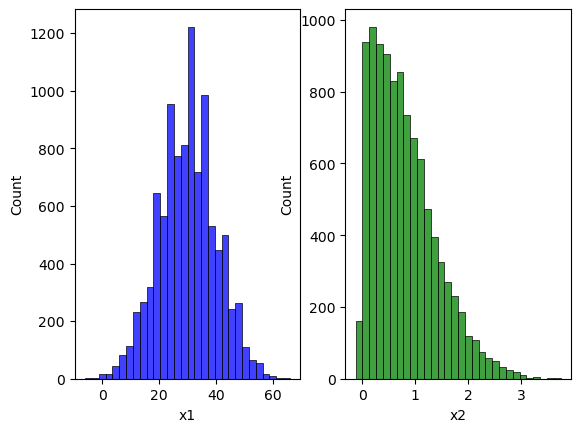

In [4]:
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2)
sns.histplot(x='x1', data = df, bins=30, color='blue', ax=ax1)
sns.histplot(x='x2', data=df, bins=30, color='green', ax=ax2)
plt.show();

Mean:  29.9199
Std Dev:  10.042099798689334
Min:  -6.0
Max:  66.0


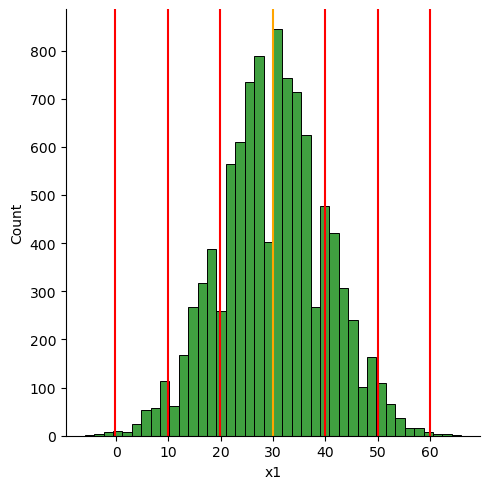

In [5]:
mu = df.x1.mean()
sigma = df.x1.std()
minimum = df.x1.min()
maximum = df.x1.max()
print("Mean: ", mu)
print("Std Dev: ", sigma)
print("Min: ", minimum)
print("Max: ", maximum)

sns.displot(x='x1',data=df, kind='hist', bins=40, color='green')
plt.axvline(df.x1.mean(), color='orange')
for i in [-3, -2, -1, 1, 2, 3]:
    plt.axvline(mu+i*sigma, color='red')
plt.show();

##  c. Identify Outliers
#### Option 1: Find values which are below $\large \mu - 3\sigma$ or above $\large \mu + 3\sigma$

In [6]:
#Finding boundry values
lower_limit = mu - 3*sigma
upper_limit = mu + 3*sigma
print("Lower Limit", lower_limit)
print("Upper Limit", upper_limit)

Lower Limit -0.20639939606800084
Upper Limit 60.046199396068


In [7]:
df[df.x1>upper_limit]

,x1,x2,y
1322,63.0,1.351085,36.0
2195,64.0,1.069022,37.0
2411,63.0,0.032994,36.0
5544,62.0,1.907387,36.0
6171,61.0,0.694187,35.0
6668,66.0,0.920489,38.0
9500,61.0,1.635512,35.0


In [8]:
df[df.x1 < lower_limit]

,x1,x2,y
765,-1.0,0.158337,5.0
825,-1.0,1.095189,5.0
1138,-2.0,0.044623,4.0
3493,-1.0,-0.001617,5.0
6639,-4.0,2.498395,3.0
6707,-1.0,1.630756,4.0
7116,-3.0,0.292362,4.0
7825,-4.0,0.053568,3.0
8832,-6.0,0.885744,2.0
9443,-2.0,0.263597,4.0


In [9]:
df[(df.x1 > upper_limit)  |  (df.x1 < lower_limit)]

,x1,x2,y
765,-1.0,0.158337,5.0
825,-1.0,1.095189,5.0
1138,-2.0,0.044623,4.0
1322,63.0,1.351085,36.0
2195,64.0,1.069022,37.0
2411,63.0,0.032994,36.0
3493,-1.0,-0.001617,5.0
5544,62.0,1.907387,36.0
6171,61.0,0.694187,35.0
6639,-4.0,2.498395,3.0


#### Option 2: Find $Z= \frac{x_i - \mu}{\sigma}$ of corresponding `x1` values and ouliers will be values where $\hspace{.5cm} Z < -3 \hspace{.5cm}\text{OR}\hspace{.5cm} Z > 3$

In [ ]:
df1 = df.copy()
df1['z_x1'] = (df['x1'] - df['x1'].mean()) / df['x1'].std()
df1

In [ ]:
df1[(df1.z_x1 < -3)  |  (df1.z_x1 > 3)]

##  d. What to do with the Outliers
- **Trimming** 
- **Capping (Winsorization)** 
- **Discretization:**

###  (i) Remove the outliers (Trimming)
#### Option 1: Remove values which are below $\large \mu - 3\sigma$ or above $\large \mu + 3\sigma$

In [10]:
new_df = df[(df.x1 <= upper_limit)  &  (df.x1 >= lower_limit)]
new_df

,x1,x2,y
0,11.0,0.140452,11.0
1,19.0,0.473867,15.0
2,31.0,1.713352,20.0
3,16.0,0.888953,13.0
4,36.0,0.118194,23.0
...,...,...,...
9995,30.0,1.705223,20.0
9996,28.0,2.444101,19.0
9997,37.0,1.089873,24.0
9998,36.0,0.776210,23.0


#### Option 2: Remove values  where $\hspace{.5cm} Z < -3 \hspace{.5cm}\text{OR}\hspace{.5cm} Z > 3$

In [ ]:
df1

In [ ]:
new_df1 = df1[(df1.z_x1 <= 3)  &  (df1.z_x1 >= -3)]
new_df1

In [ ]:
new_df1 = new_df1.drop('z_x1',axis=1)
new_df1

### (ii)  Replace outlier with upper value (Capping/Winsorization)
>- `np.where(condition,a,b)`
>- If condition is true then return `a` else return `b`

In [11]:
capped_df = df.copy()
capped_df['x1'] = np.where(df['x1'] < lower_limit, lower_limit,
                   (np.where(df['x1'] > upper_limit, upper_limit, df['x1']))
                   )
capped_df

,x1,x2,y
0,11.0,0.140452,11.0
1,19.0,0.473867,15.0
2,31.0,1.713352,20.0
3,16.0,0.888953,13.0
4,36.0,0.118194,23.0
...,...,...,...
9995,30.0,1.705223,20.0
9996,28.0,2.444101,19.0
9997,37.0,1.089873,24.0
9998,36.0,0.776210,23.0


**Verify**

In [ ]:
capped_df.describe()

# 2. IQR Method to Identify Outliers

- Quantiles divides a distribution and the most common are `median`, `quartiles`, `deciles`, and `percentiles`.
- **Quartiles:**, as their name suggests, are quantiles that divide a distribution into quarters by splitting a rank-ordered dataset into four equal parts. 
    - 1st Quartile Q1 is the same as the 25th percentile.
    - 2nd Quartile Q2 is the same as 50th percentile.
    - 3rd Quratile Q3 is same as 75th percentile
- Inter Quartile Range is the difference between the third quartile(Q3) and the first Quartile (Q1)

<img align="centre" width="700" height="750"  src="images/iqr2.png"  >


- A boxplot is a method that is used to graphically represent numerical data through their quartiles.
- A boxplot is a very simple but effective way to visualize outliers. Think about the lower and upper whiskers as the boundaries of the data distribution. Any data points that show above or below the whiskers, can be considered outliers or anomalous.
- Outliers in this case are defined as the observations that are below (Q1 − 1.5x IQR) or boxplot lower whisker or above (Q3 + 1.5x IQR) or boxplot upper whisker.


<img align="center" width="600" src="images/iqr-outlier.png"  >

##  a.  Load Dataset

In [ ]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
df = pd.read_csv('datasets/outliers.csv')
df

##  b. Check the Distributions

In [ ]:
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2)
sns.histplot(x='x1', data = df, bins=30, color='blue', ax=ax1)
sns.histplot(x='x2', data=df, bins=30, color='green', ax=ax2)
plt.show();

##  c. Identify Outliers

**Draw the BoxPlot:**

In [ ]:
import seaborn as sns
sns.boxplot(x=df['x2'], data=df);

**Calculate IQR:**

In [ ]:
q1 = df['x2'].quantile(0.25)
q3 = df['x2'].quantile(0.75)
iqr = q3 - q1
iqr

**Calculate Lower and Upper Limit:**

In [ ]:
lower_limit = q1 - 1.5*iqr
upper_limit = q3  + 1.5*iqr
lower_limit, upper_limit

**Find Outliers:** Below $\hspace{.2cm} Q1 - 1.5\times\text{IQR}\hspace{.5cm}$ or above $\hspace{.2cm}Q3 + 1.5*\text{IQR}$)

In [ ]:
df[df['x2'] < lower_limit]

In [ ]:
df[df['x2'] > upper_limit]

##  d. What to do with the Outliers

###  (i) Remove the outliers (Trimming)

In [ ]:
new_df = df[(df.x2 >= lower_limit)  &  (df.x2 <= upper_limit)]
new_df.shape

In [ ]:
# Compare the results
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(nrows=2, ncols=2)
sns.histplot(x='x2', data=df, bins=30, color='blue', ax=ax1)
sns.histplot(x='x2', data=new_df, bins=30, color='green', ax=ax2)
sns.boxplot(x='x2', data=df, ax=ax3)
sns.boxplot(x='x2', data=new_df, ax=ax4);

### (ii)  Replace outlier with upper value (Capping/Winsorization)
>- `np.where(condition,a,b)`
>- If condition is true then return `a` else return `b`

In [ ]:
capped_df = df.copy()
capped_df['x2'] = np.where(df['x2'] < lower_limit, lower_limit,
                   (np.where(df['x2'] > upper_limit, upper_limit, df['x2']))
                   )
capped_df.shape

In [ ]:
# Compare the results
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(nrows=2, ncols=2)
sns.histplot(x='x2', data=df, bins=30, color='blue', ax=ax1)
sns.histplot(x='x2', data=capped_df, bins=30, color='green', ax=ax2)
sns.boxplot(x='x2', data=df, ax=ax3)
sns.boxplot(x='x2', data=capped_df, ax=ax4);

## 3. Percentile Method to Identify Outliers

- For `Normally distributed` data we have used empirical relations of Normal distribution, which says that the data points which fall below $\large \mu - 3\sigma$ or above $\large \mu + 3\sigma$ are outliers.
- For `Skewed distributions`, we use Inter-Quartile Range (IQR) proximity rule, which says that the data points which fall below $Q1 – 1.5\times IQR$ or above $Q3 + 1.5 \times IQR$ are outliers.
- For `Other distributions`, we use **Percentile-based approach**, in which you specify a particular threshold value (percentile) below and above which all data points are considered as outliers.

<img align="centre" width="600" height="750"  src="images/percentile.jpg"  >

##  a.  Load Dataset

In [ ]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
df = pd.read_csv('datasets/outliers.csv')
df

##  b. Check the Distributions

In [ ]:
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2)
sns.histplot(x='x1', data = df, bins=30, color='blue', ax=ax1)
sns.boxplot(x=df['x1'], ax=ax2)
plt.show();

##  c. Identify Outliers
- Assume that all values below 1% and 99% are outliers

In [ ]:
lower_limit = df['x1'].quantile(0.01)
upper_limit = df['x1'].quantile(0.99)

lower_limit, upper_limit

##  d. What to do with the Outliers

###  (i) Remove the outliers (Trimming)

In [ ]:
new_df = df[(df.x1 >= lower_limit)  &  (df.x1 <= upper_limit)]
new_df.shape

In [ ]:
# Compare the results
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(nrows=2, ncols=2)
sns.histplot(x='x1', data=df, bins=30, color='blue', ax=ax1)
sns.histplot(x='x1', data=new_df, bins=30, color='green', ax=ax2)
sns.boxplot(x='x1', data=df, ax=ax3)
sns.boxplot(x='x1', data=new_df, ax=ax4);

### (ii)  Replace outlier with upper value (Capping/Winsorization)
>- `np.where(condition,a,b)`
>- If condition is true then return `a` else return `b`

In [ ]:
capped_df = df.copy()
capped_df['x1'] = np.where(df['x1'] < lower_limit, lower_limit,
                   (np.where(df['x1'] > upper_limit, upper_limit, df['x1']))
                   )
capped_df.shape

In [ ]:
# Compare the results
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(nrows=2, ncols=2)
sns.histplot(x='x1', data=df, bins=30, color='blue', ax=ax1)
sns.histplot(x='x1', data=capped_df, bins=30, color='green', ax=ax2)
sns.boxplot(x='x1', data=df, ax=ax3)
sns.boxplot(x='x1', data=capped_df, ax=ax4);

## 4. Multi-Variate Analysis to Handle Outliers
<img align="right" width="500" src="images/scatterplot-outlier.png"  >

- We use multivariate methods to find the outliers that only show up within combinations of observations from two or more different variables. 
    - Scatterplot matrices
    - Boxplots
- There are a bundle of methods that you may come accross in literature like:
    - Depth-based methods
    - Distance-based methods
    - Density-based methods
    - Mahalanobis distance based methods


## a. Use Scatterplot

##  Load Dataset

In [12]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
df = pd.read_csv('datasets/Ames_Housing_Data.csv')
df

,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2925,923275080,80,RL,37.0,7937,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,GdPrv,NaN,0,3,2006,WD,Normal,142500
2926,923276100,20,RL,NaN,8885,Pave,NaN,IR1,Low,AllPub,...,0,NaN,MnPrv,NaN,0,6,2006,WD,Normal,131000
2927,923400125,85,RL,62.0,10441,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,Shed,700,7,2006,WD,Normal,132000
2928,924100070,20,RL,77.0,10010,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2006,WD,Normal,170000


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 81 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   PID              2930 non-null   int64  
 1   MS SubClass      2930 non-null   int64  
 2   MS Zoning        2930 non-null   object 
 3   Lot Frontage     2440 non-null   float64
 4   Lot Area         2930 non-null   int64  
 5   Street           2930 non-null   object 
 6   Alley            198 non-null    object 
 7   Lot Shape        2930 non-null   object 
 8   Land Contour     2930 non-null   object 
 9   Utilities        2930 non-null   object 
 10  Lot Config       2930 non-null   object 
 11  Land Slope       2930 non-null   object 
 12  Neighborhood     2930 non-null   object 
 13  Condition 1      2930 non-null   object 
 14  Condition 2      2930 non-null   object 
 15  Bldg Type        2930 non-null   object 
 16  House Style      2930 non-null   object 
 17  Overall Qual  

In [14]:
df.corr(numeric_only=True)

,PID,MS SubClass,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Mas Vnr Area,BsmtFin SF 1,...,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,SalePrice
PID,1.000000,-0.001281,-0.096918,0.034868,-0.263147,0.104451,-0.343388,-0.157111,-0.229283,-0.098375,...,-0.051135,-0.071311,0.162519,-0.024894,-0.025735,-0.002845,-0.008260,-0.050455,0.009579,-0.246521
MS SubClass,-0.001281,1.000000,-0.420135,-0.204613,0.039419,-0.067349,0.036579,0.043397,0.002730,-0.060075,...,-0.017310,-0.014823,-0.022866,-0.037956,-0.050614,-0.003434,-0.029254,0.000350,-0.017905,-0.085092
Lot Frontage,-0.096918,-0.420135,1.000000,0.491313,0.212042,-0.074448,0.121562,0.091712,0.222407,0.215583,...,0.120084,0.163040,0.012758,0.028564,0.076666,0.173947,0.044476,0.011085,-0.007547,0.357318
Lot Area,0.034868,-0.204613,0.491313,1.000000,0.097188,-0.034759,0.023258,0.021682,0.126830,0.191555,...,0.157212,0.103760,0.021868,0.016243,0.055044,0.093775,0.069188,0.003859,-0.023085,0.266549
Overall Qual,-0.263147,0.039419,0.212042,0.097188,1.000000,-0.094812,0.597027,0.569609,0.429418,0.284118,...,0.255663,0.298412,-0.140332,0.018240,0.041615,0.030399,0.005179,0.031103,-0.020719,0.799262
Overall Cond,0.104451,-0.067349,-0.074448,-0.034759,-0.094812,1.000000,-0.368773,0.047680,-0.135340,-0.050935,...,0.020344,-0.068934,0.071459,0.043852,0.044055,-0.016787,0.034056,-0.007295,0.031207,-0.101697
Year Built,-0.343388,0.036579,0.121562,0.023258,0.597027,-0.368773,1.000000,0.612095,0.313292,0.279870,...,0.228964,0.198365,-0.374364,0.015803,-0.041436,0.002213,-0.011011,0.014577,-0.013197,0.558426
Year Remod/Add,-0.157111,0.043397,0.091712,0.021682,0.569609,0.047680,0.612095,1.000000,0.196928,0.151790,...,0.217857,0.241748,-0.220383,0.037412,-0.046888,-0.011410,-0.003132,0.018048,0.032652,0.532974
Mas Vnr Area,-0.229283,0.002730,0.222407,0.126830,0.429418,-0.135340,0.313292,0.196928,1.000000,0.301872,...,0.165467,0.143748,-0.110787,0.013778,0.065643,0.004617,0.044934,-0.000276,-0.017715,0.508285
BsmtFin SF 1,-0.098375,-0.060075,0.215583,0.191555,0.284118,-0.050935,0.279870,0.151790,0.301872,1.000000,...,0.224010,0.124947,-0.100455,0.050541,0.095874,0.084140,0.092886,-0.001155,0.022397,0.432914


**Check out the correlation between the input features and output label `SalePrice` only:**

In [15]:
df.corr(numeric_only=True)['SalePrice']

PID               -0.246521
MS SubClass       -0.085092
Lot Frontage       0.357318
Lot Area           0.266549
Overall Qual       0.799262
Overall Cond      -0.101697
Year Built         0.558426
Year Remod/Add     0.532974
Mas Vnr Area       0.508285
BsmtFin SF 1       0.432914
BsmtFin SF 2       0.005891
Bsmt Unf SF        0.182855
Total Bsmt SF      0.632280
1st Flr SF         0.621676
2nd Flr SF         0.269373
Low Qual Fin SF   -0.037660
Gr Liv Area        0.706780
Bsmt Full Bath     0.276050
Bsmt Half Bath    -0.035835
Full Bath          0.545604
Half Bath          0.285056
Bedroom AbvGr      0.143913
Kitchen AbvGr     -0.119814
TotRms AbvGrd      0.495474
Fireplaces         0.474558
Garage Yr Blt      0.526965
Garage Cars        0.647877
Garage Area        0.640401
Wood Deck SF       0.327143
Open Porch SF      0.312951
Enclosed Porch    -0.128787
3Ssn Porch         0.032225
Screen Porch       0.112151
Pool Area          0.068403
Misc Val          -0.015691
Mo Sold            0

In [16]:
df.corr(numeric_only=True)['SalePrice'].sort_values()

PID               -0.246521
Enclosed Porch    -0.128787
Kitchen AbvGr     -0.119814
Overall Cond      -0.101697
MS SubClass       -0.085092
Low Qual Fin SF   -0.037660
Bsmt Half Bath    -0.035835
Yr Sold           -0.030569
Misc Val          -0.015691
BsmtFin SF 2       0.005891
3Ssn Porch         0.032225
Mo Sold            0.035259
Pool Area          0.068403
Screen Porch       0.112151
Bedroom AbvGr      0.143913
Bsmt Unf SF        0.182855
Lot Area           0.266549
2nd Flr SF         0.269373
Bsmt Full Bath     0.276050
Half Bath          0.285056
Open Porch SF      0.312951
Wood Deck SF       0.327143
Lot Frontage       0.357318
BsmtFin SF 1       0.432914
Fireplaces         0.474558
TotRms AbvGrd      0.495474
Mas Vnr Area       0.508285
Garage Yr Blt      0.526965
Year Remod/Add     0.532974
Full Bath          0.545604
Year Built         0.558426
1st Flr SF         0.621676
Total Bsmt SF      0.632280
Garage Area        0.640401
Garage Cars        0.647877
Gr Liv Area        0

**Checkout Scatterplot of input feature `Overall Qual` with `SalePrice`:**

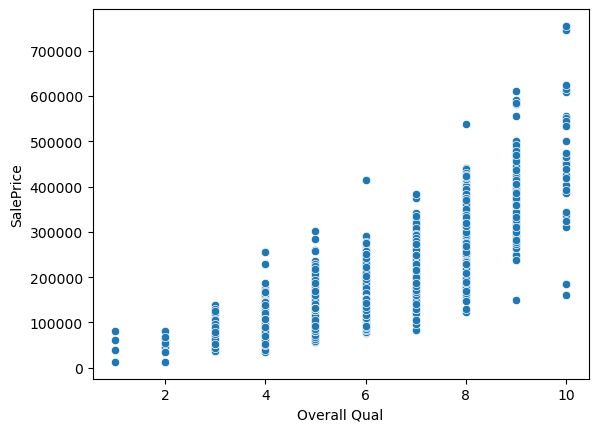

In [17]:
sns.scatterplot(x='Overall Qual', y='SalePrice', data=df);

> Type of OverallQuality column is categorical having valuesfrom 1 to 10

**Checkout Scatterplot of input feature `Gr Liv Area` with `SalePrice`:**

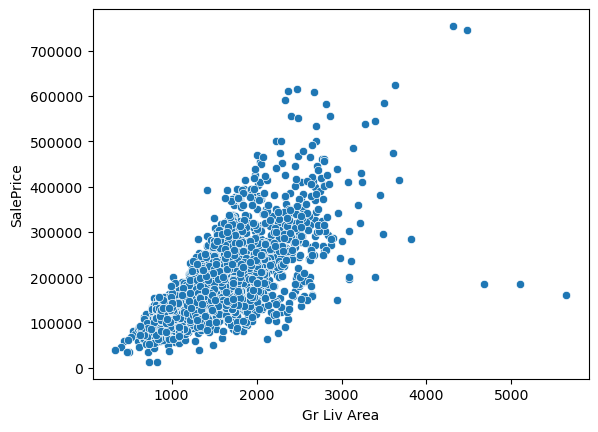

In [18]:
sns.scatterplot(x='Gr Liv Area', y='SalePrice', data=df);

In [19]:
df[(df['Gr Liv Area']>4000) & (df['SalePrice']<200000)]

,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
1498,908154235,60,RL,313.0,63887,Pave,NaN,IR3,Bnk,AllPub,...,480,Gd,NaN,NaN,0,1,2008,New,Partial,160000
2180,908154195,20,RL,128.0,39290,Pave,NaN,IR1,Bnk,AllPub,...,0,NaN,NaN,Elev,17000,10,2007,New,Partial,183850
2181,908154205,60,RL,130.0,40094,Pave,NaN,IR1,Bnk,AllPub,...,0,NaN,NaN,NaN,0,10,2007,New,Partial,184750


In [20]:
indices = df[(df['Gr Liv Area']>4000) & (df['SalePrice']<200000)].index
indices

Int64Index([1498, 2180, 2181], dtype='int64')

In [21]:
new_df = df.drop(indices,axis=0)
new_df.shape

(2927, 81)

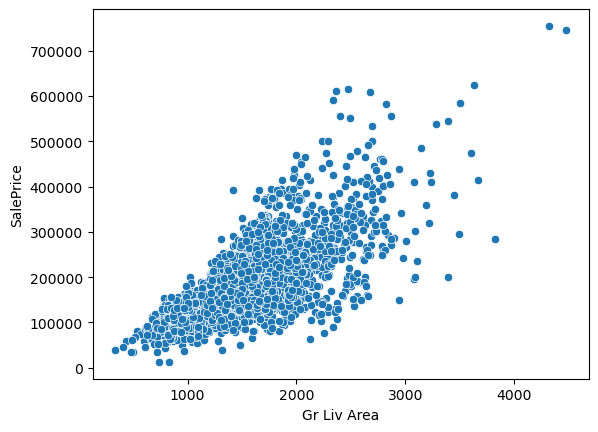

In [22]:
sns.scatterplot(x='Gr Liv Area', y='SalePrice', data=new_df);

In [ ]:
df.to_csv("datasets/Ames_outliers_removed.csv",index=False)

- **Quartiles:**, as their name suggests, are quantiles that divide a distribution into quarters by splitting a rank-ordered dataset into four equal parts. 
- Inter Quartile Range is the difference between the third quartile(Q3) and the first Quartile (Q1)

<img align="centre" width="700" height="750"  src="images/iqr2.png"  >


- A boxplot is a method that is used to graphically represent numerical data through their quartiles.
- A boxplot is a very simple but effective way to visualize outliers. Think about the lower and upper whiskers as the boundaries of the data distribution. Any data points that show above or below the whiskers, can be considered outliers or anomalous.
- Outliers in this case are defined as the observations that are below (Q1 − 1.5x IQR) or boxplot lower whisker or above (Q3 + 1.5x IQR) or boxplot upper whisker.


<img align="center" width="600" src="images/iqr-outlier.png"  >